In [2]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
device = 'cuda:5'

In [5]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [7]:
adata.obs.anno_man.cat.categories

Index(['Bas/MC prog', 'Eos', 'Ery', 'HSC', 'Int prog', 'Ly', 'Meg',
       'Mono/DC prog', 'Neu'],
      dtype='object')

In [ ]:
cellstate_key = "DM_scaled"
n_dimension = 10
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [19]:
Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key=None,
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


# load model

In [10]:
model_ckpt = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt"
model_ckpt = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=87-total_loss=1.34044445.ckpt"
pde_model = models.pde_params.load_from_checkpoint(model_ckpt)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


<Axes: title={'center': 'anno_man'}, xlabel='UMAP1', ylabel='UMAP2'>

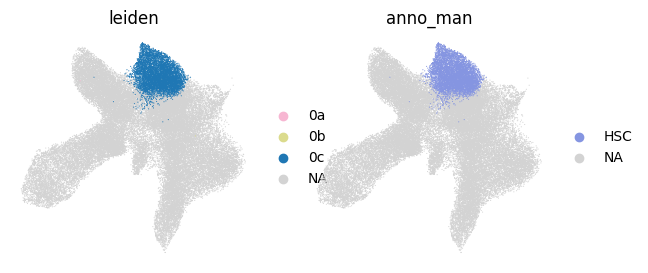

In [9]:
fig, axs = plt.subplots(1,2, figsize=(7,3))
sc.pl.umap(adata, color='leiden', groups=['0a', '0b', '0c'], ax=axs[0], show=False, frameon=False)
sc.pl.umap(adata, color='anno_man', groups='HSC', ax=axs[1], show=False, frameon=False)

# go for all HSC cells

In [10]:
n_interval = 10
ncell = 100

In [11]:
from torch import nn
import gc
import torch.nn.functional as F

In [27]:
pde_model = pde_model.to(device)

In [13]:
from PINN.models import Density_Transfer

In [28]:
DT = Density_Transfer(pde_model)

In [17]:
from tqdm.auto import tqdm

In [31]:
# initial cell
n_interval = 10
ncell = 90

timepoint_tx_days = sorted(adata.obs.timepoint_tx_days.unique())
t0 = timepoint_tx_days[0]

Tmaps = {}
Tmaps_norm = {}
S_traj_lookup = {}
HSC_cbs = []

for it,t in tqdm(enumerate(timepoint_tx_days[:-1])):
    # if it==0:
    #     torch.cuda.memory._record_memory_history()

    integrate_time = np.linspace(t/t0, timepoint_tx_days[it+1]/t0 ,n_interval+1) / pde_model.time_scale_factor
    print(integrate_time)

    # find cell of time
    start_cell = adata.obs.query("`anno_man` == 'HSC' & `timepoint_tx_days` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)

    # define initital density and cellstates
    cell_index = [np.where(adata.obs_names == x)[0].item() for x in start_cell]
    u0 = Dataset.u_b[it, cell_index].float().to(device)
    s0 = torch.from_numpy(Dataset.cellstate[cell_index]).float().to(device)

    S_trajectory = DT.cellstate_drift(s0, integrate_time)
    Tmaps_t, Tmaps_t_norm = DT.transition_by_batch(s0, u0, integrate_time, n_interval=n_interval, ncell=ncell)

    del u0, s0
    
    S_traj_lookup[str(t)] = S_trajectory
    Tmaps_norm[str(t)] = Tmaps_t_norm
    Tmaps[str(t)] = Tmaps_t

0it [00:00, ?it/s]

[0.2        0.22666667 0.25333333 0.28       0.30666667 0.33333333
 0.36       0.38666667 0.41333333 0.44       0.46666667]
[0.46666667 0.5        0.53333333 0.56666667 0.6        0.63333333
 0.66666667 0.7        0.73333333 0.76666667 0.8       ]
[0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
[1.8        1.94666667 2.09333333 2.24       2.38666667 2.53333333
 2.68       2.82666667 2.97333333 3.12       3.26666667]
[3.26666667 3.44666667 3.62666667 3.80666667 3.98666667 4.16666667
 4.34666667 4.52666667 4.70666667 4.88666667 5.06666667]
[5.06666667 5.30666667 5.54666667 5.78666667 6.02666667 6.26666667
 6.50666667 6.74666667 6.98666667 7.22666667 7.46666667]
[ 7.46666667  7.79333333  8.12        8.44666667  8.77333333  9.1
  9.42666667  9.75333333 10.08       10.40666667 10.73333333]
[10.73333333 11.45333333 12.17333333 12.89333333 13.61333333 14.33333333
 15.05333333 15.77333333 16.49333333 17.21333333 17.93333333]


# resume

In [9]:
##
# v4 , constant time interval = 3

# np.save("results/tompos_Tmap/Cellstate_traj_tplus3_v4.npy", S_traj_lookup)
# np.save("results/tompos_Tmap/Tmaps_norm_tplus3_v4.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_TM1_tplus3_v4.npy", Tmaps)

# S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_traj_tplus3_v4.npy", allow_pickle=True).item()
# Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_tplus3_v4.npy", allow_pickle=True).item()
# Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_tplus3_v4.npy", allow_pickle=True).item()

## 
# v4 , interval by pop t
# np.save("results/tompos_Tmap/Cellstate_traj_TM1_v4.npy", S_traj_lookup)
# np.save("results/tompos_Tmap/Tmaps_norm_TM1_v4.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_TM1_v4.npy", Tmaps)

S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_traj_TM1_v4.npy", allow_pickle=True).item()
Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_TM1_v4.npy", allow_pickle=True).item()
Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_v4.npy", allow_pickle=True).item()

##
# v0
# version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt
# np.save("results/tompos_Tmap/Tmaps_norm.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_left.npy", Tmaps)

# S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_v0.npy", allow_pickle=True).item()
# Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm.npy", allow_pickle=True).item()
# Tmaps = np.load("results/tompos_Tmap/Tmaps_left.npy", allow_pickle=True).item()

In [10]:
from PINN.functions import eval_funs as ef

In [26]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [41]:
nn, annoy_idx = ef.assign_nearest_cell(S_traj_lookup['3'].reshape(-1,10), adata, cellstate_key='DM_scaled', n_dimension=10, return_model=True)
adata.obs['dpt_pseudotime'].iloc[nn[0]]

481-SS2                                0.010056
7w11w_SITTC3_GAGGCCTTCGTTATCT-1-10x    0.010344
5mo_SIGAD9_AGCTCAATCAGGGTAG-1-10x      0.007021
16w_SITTE12_TCCTTCTTCTACACAG-1-10x     0.006751
7w11w_SITTC3_ATGAGGGAGGTTCCAT-1-10x    0.009405
2w4w_SITTC4_CCTCCTCGTAGTTACC-1-10x     0.014923
2w4w_SITTD4_TATTCCAAGGCGTTGA-1-10x     0.014830
9mo_SIGAF3_GTGATGTCAGACACAG-1-10x      0.006604
7w11w_SITTC3_TCATCATAGAGGGTAA-1-10x    0.008411
2w4w_SITTC4_TCATTACTCCTATTTG-1-10x     0.010966
7w11w_SITTC3_CTACGGGCAGTGGTGA-1-10x    0.010156
827-SS2                                0.015485
Name: dpt_pseudotime, dtype: float32

In [26]:
def plot_transport_map_example(Tmaps, n_example=2, log=False, kws={}):

    fig, axs = plt.subplots(n_example, 8, figsize=(12,n_example*1.5+1), **kws)

    i = 0
    for t, tmap in Tmaps.items():
        tmap = tmap
        tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]
        
        for j in range(n_example):
            
            seed = np.random.randint(0,tmap_nz.shape[0])

            if log:
                axs[j, i].matshow(np.where(tmap_nz[seed]==0, np.nan, np.log(tmap_nz[seed]+1e-30)))
            else:
                axs[j, i].matshow(np.where(tmap_nz[seed]==0, np.nan, tmap_nz[seed]))
        
            axs[j,i].set_xticklabels('')
            axs[j,i].set_yticklabels('')

        axs[0,i].set_title(t)
        i+=1

    for j in range(n_example):
        axs[j,0].set_ylabel('cells')
        
    axs[n_example-1,3].set_xlabel("  "*10+'trajectories')

    return fig, axs

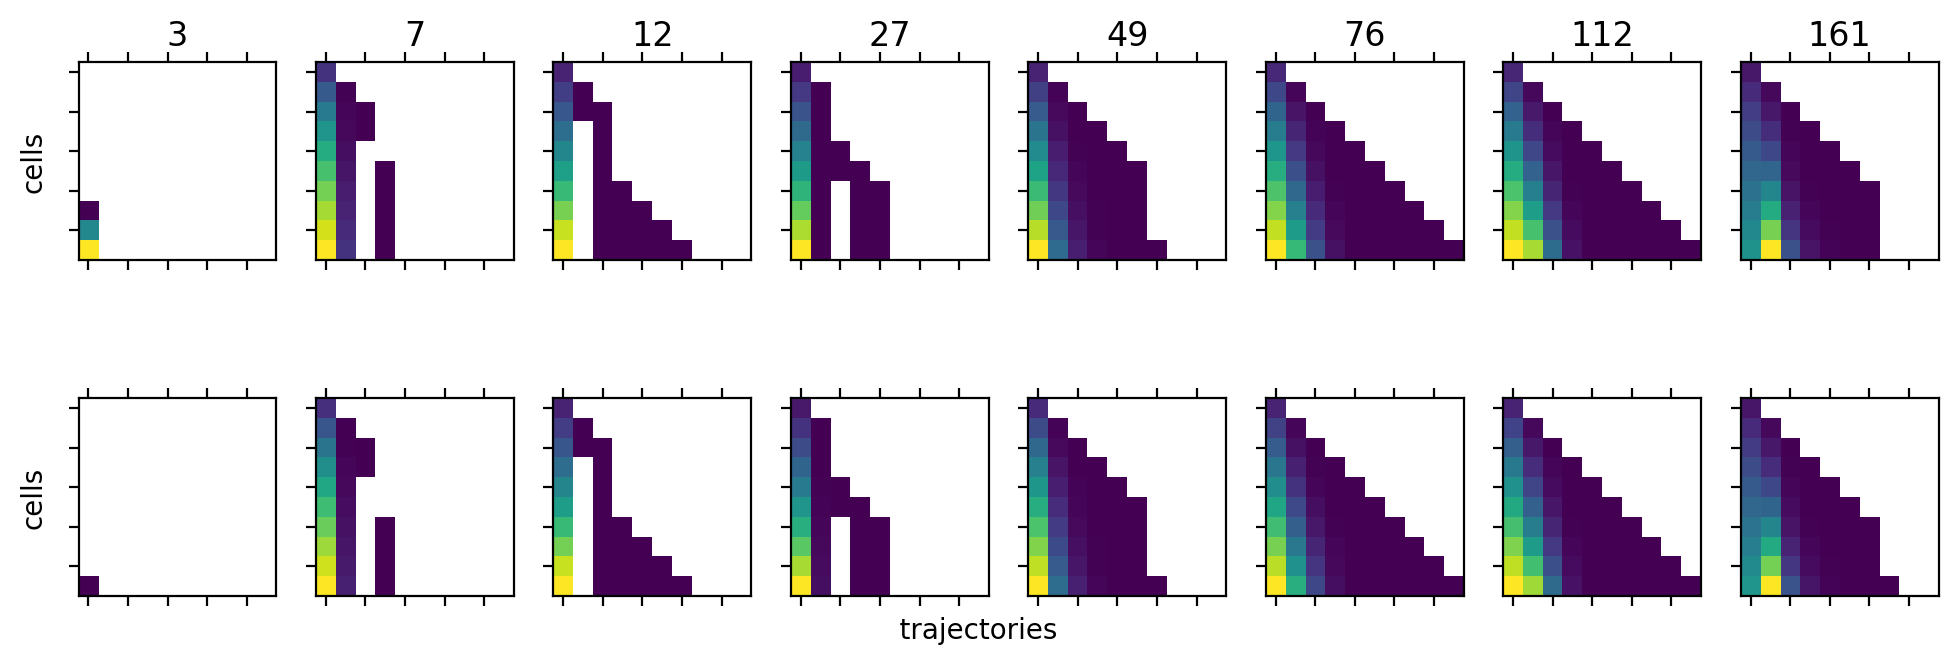

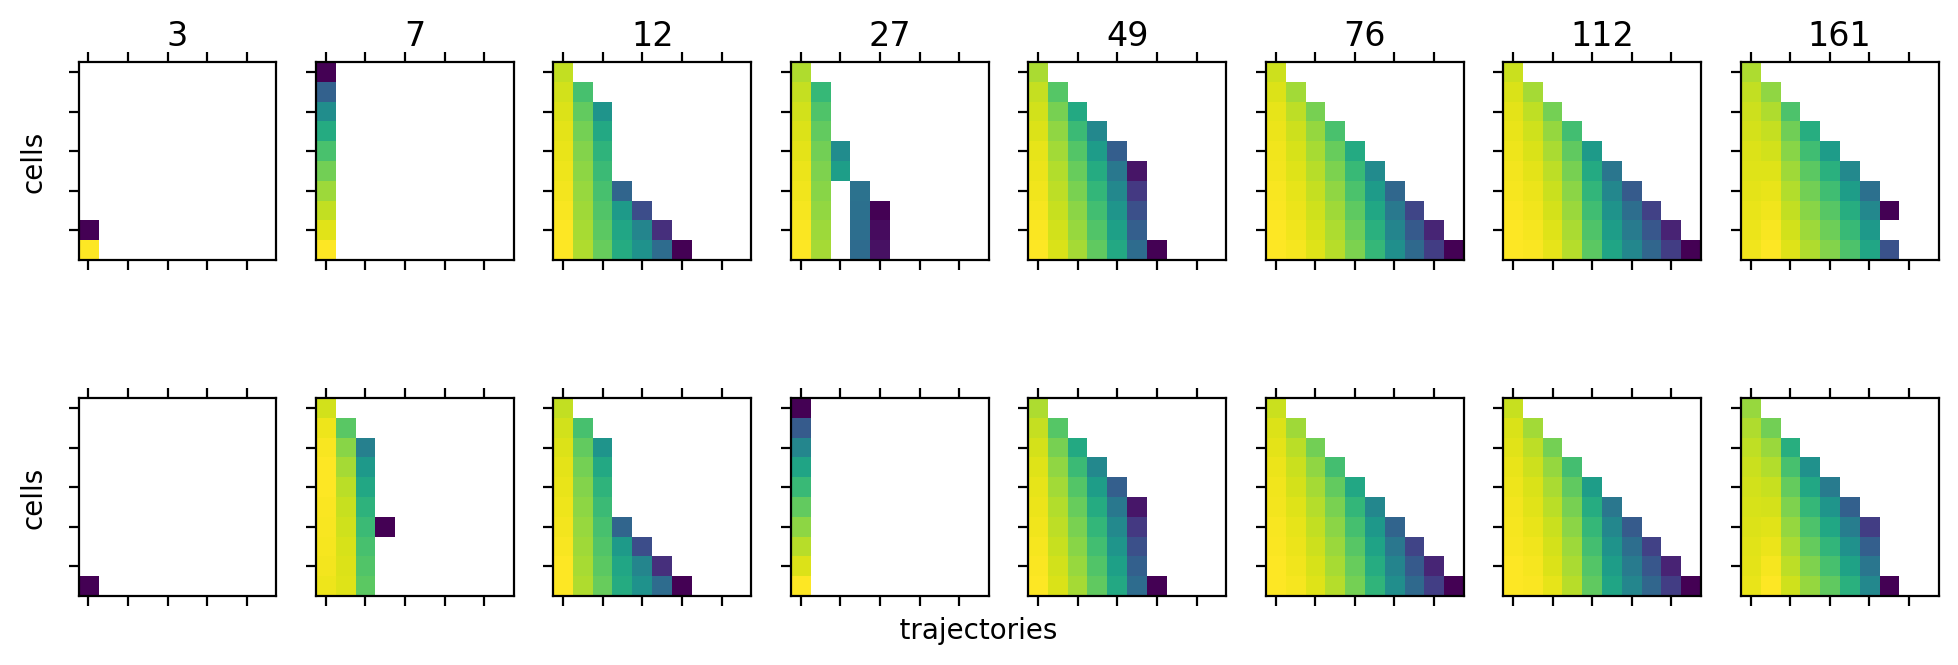

In [27]:
plot_transport_map_example(Tmaps, n_example=2, log=False, kws={'dpi':200});
plot_transport_map_example(Tmaps, n_example=2, log=True, kws={'dpi':200});

Text(0.5, 0, '                    trajectories')

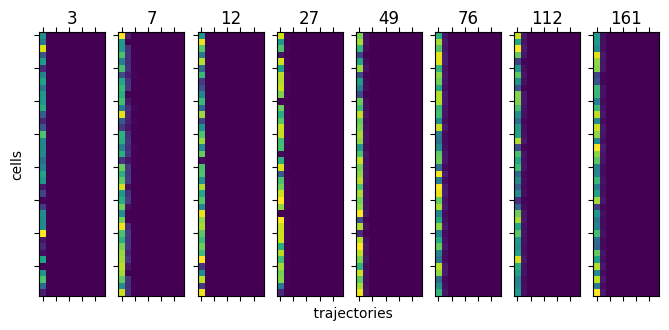

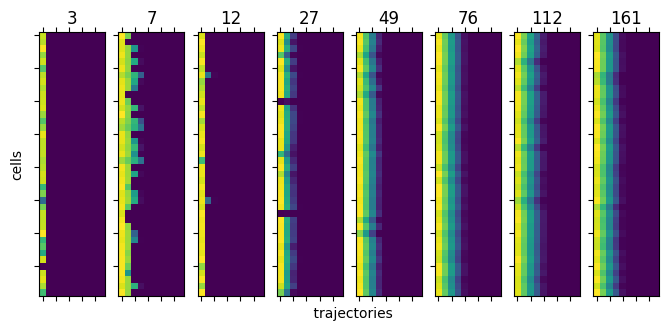

In [ ]:
fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():

    tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]

    axs[i].matshow(np.log(tmap_nz[:40,-1,:]+1e-10))
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')
    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')

In [26]:
# np.save("results/tompos_Tmap/Tmap_by_u_ratio.npy", Tmaps)

# clustering

In [59]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

def hierarchical_clustering_sklearn(matrix, num_clusters, linkage='ward'):
    """
    Perform hierarchical clustering on the rows of a matrix using sklearn and return the clustered row indices.

    Parameters:
    - matrix: numpy array, the input matrix where rows are to be clustered.
    - num_clusters: int, the number of clusters to form (truncation level).
    - linkage: str, the linkage method to use (default is 'ward').

    Returns:
    - clustered_indices: list of lists, where each sublist contains the row indices of a cluster.
    """
    # Perform hierarchical clustering using AgglomerativeClustering
    clustering = AgglomerativeClustering(n_clusters=num_clusters, linkage=linkage)
    clusters = clustering.fit_predict(matrix)
    
    # Organize row indices by cluster
    clustered_indices = [[] for _ in range(num_clusters)]
    for row_index, cluster_id in enumerate(clusters):
        clustered_indices[cluster_id].append(row_index)
    
    return clustered_indices, clusters

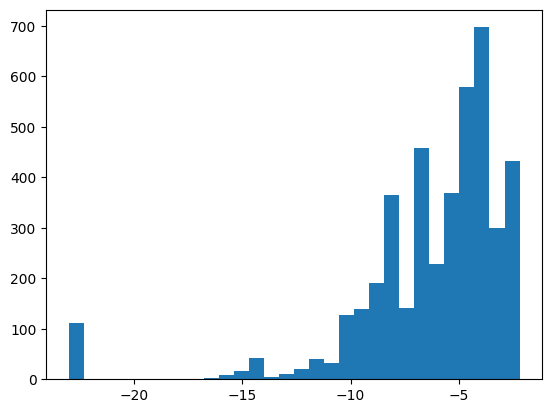

In [35]:
Tmap_all = np.concatenate(list(Tmaps.values()), axis=0)
plt.hist(np.log(Tmap_all[:,-1].sum(axis=1)+1e-10),bins=30);

In [36]:
Tmap_all_flat = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100)
nz_id = np.where(Tmap_all_flat.sum(axis=1)!=0)[0]
Tmap_all_flat[nz_id] = Tmap_all_flat[nz_id] / Tmap_all_flat[nz_id].sum(axis=1,keepdims=True)

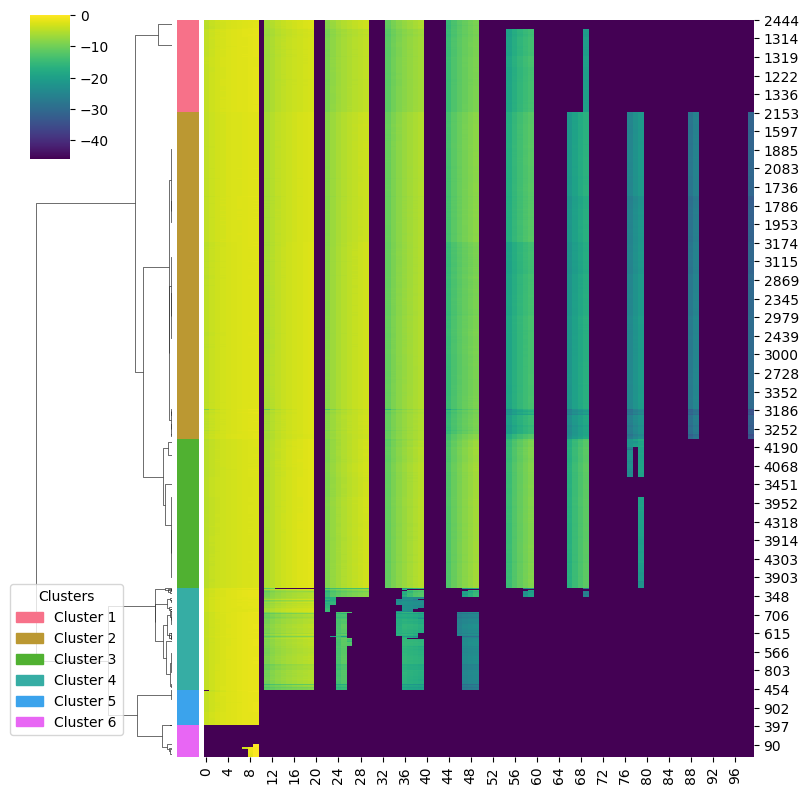

Cluster assignments: [6 6 6 ... 3 3 3]
Reordered row indices: [8275, 8430, 8548, 8557, 8593, 8615, 8622, 8628, 8280, 8623, 8624, 8631, 868, 8519, 8609, 8625]


In [44]:
num_clusters = 6
cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(np.log(Tmap_all_flat+1e-20), num_clusters, truncate_mode="level", p=3)

print("Cluster assignments:", cluster_flat)
print("Reordered row indices:", reordered_indices)

<Axes: title={'center': 'HSC_cluster_flat'}, xlabel='UMAP1', ylabel='UMAP2'>

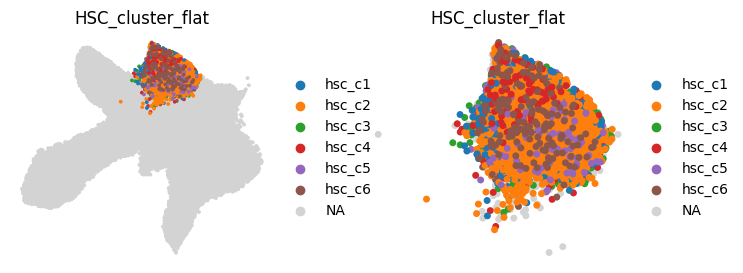

In [45]:
fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})
adata.obs['HSC_cluster_flat'] = 'na'
named_cluster_flats = ['hsc_c%s'%c for c in cluster_flat]
adata.obs.loc[np.concatenate(HSC_cbs), 'HSC_cluster_flat'] = named_cluster_flats
sc.pl.umap(adata, size=30,color='HSC_cluster_flat', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=100,color='HSC_cluster_flat', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[1], frameon=False)

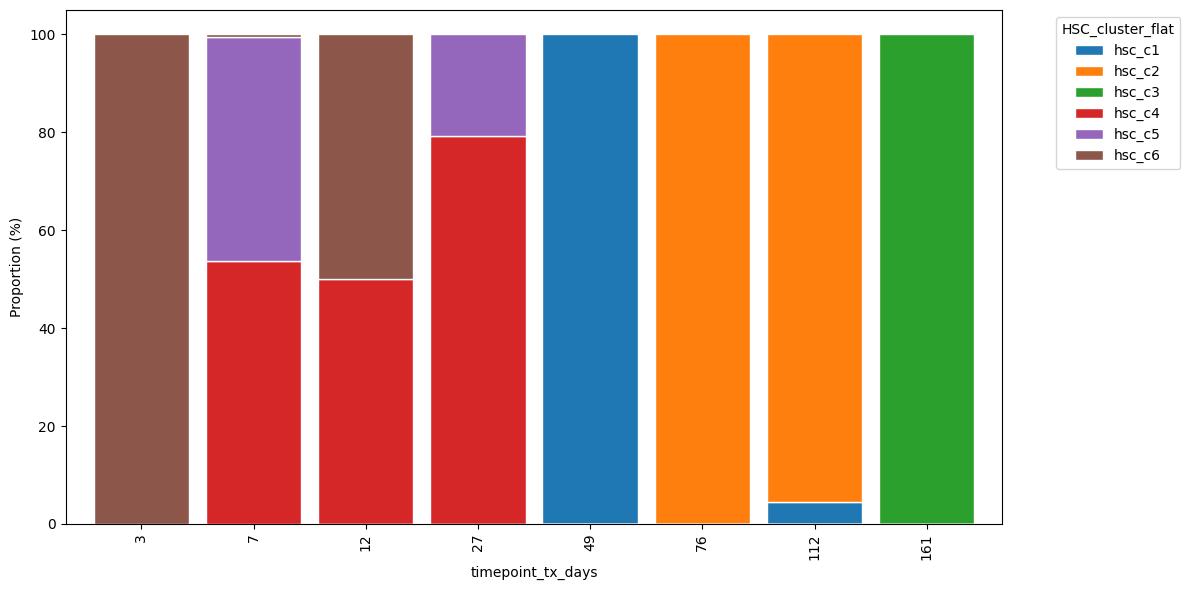

<Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>

In [46]:
PINN.pl.obs_composition(adata[np.concatenate(HSC_cbs)], 'timepoint_tx_days', 'HSC_cluster_flat')

In [39]:
Tmap_all_last = Tmap_all[:,-1,:]
Tmap_all_last
nz_id = np.where(Tmap_all_last.sum(axis=1)!=0)[0]
Tmap_all_last[nz_id] = Tmap_all_last[nz_id] / Tmap_all_last[nz_id].sum(axis=1,keepdims=True)

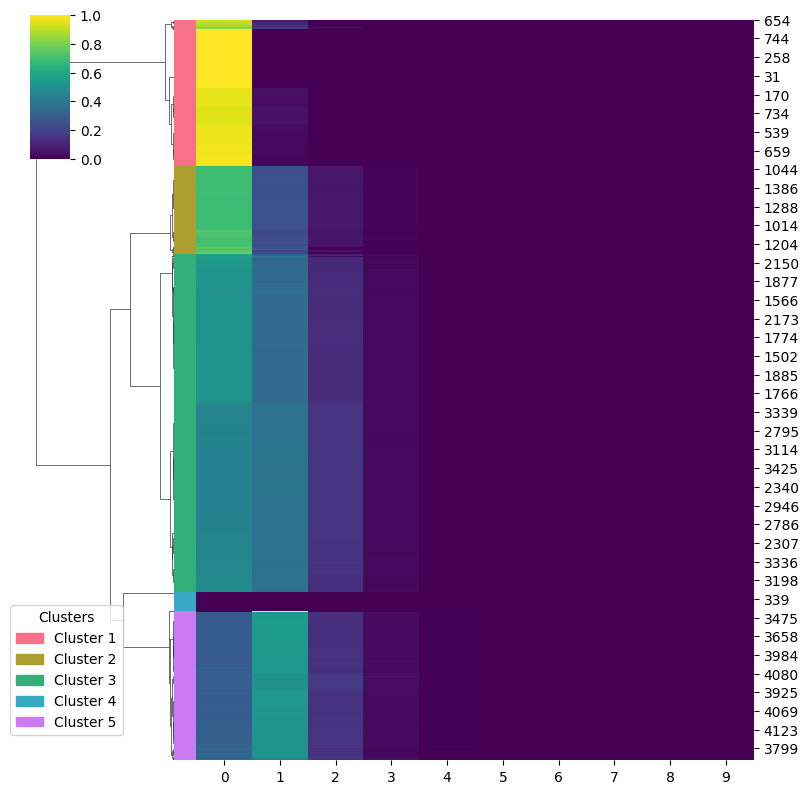

Cluster assignments: [4 4 1 ... 5 5 5]
Reordered row indices: [8559, 8571, 8572, 8602, 8324, 8470, 8610, 8612, 8622, 8625, 8626, 8631, 408, 4699, 81, 8632]


In [40]:
num_clusters = 5
log = False

if log:
    transfer_last = np.log(Tmap_all_last+1e-30)
else:
    transfer_last = Tmap_all_last

clusters, reordered_indices,g = PINN.pl.truncated_clustermap(transfer_last, num_clusters, truncate_mode="level", p=3)
print("Cluster assignments:", clusters)
print("Reordered row indices:", reordered_indices)

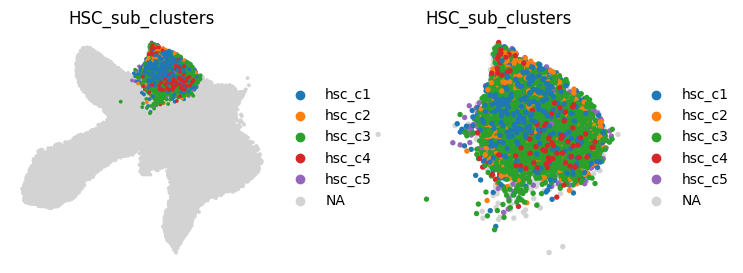

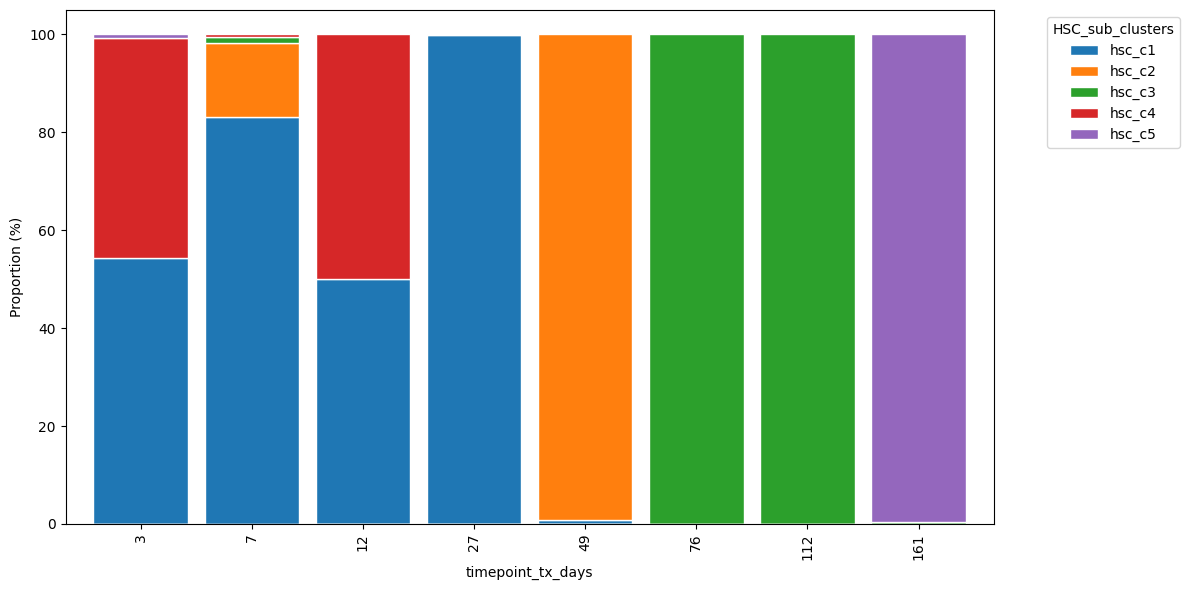

<Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>

In [42]:
adata.obs['HSC_sub_clusters'] = 'na'
named_clusters = ['hsc_c%s'%c for c in clusters]
adata.obs.loc[np.concatenate(HSC_cbs), 'HSC_sub_clusters'] = named_clusters

fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})

sc.pl.umap(adata, size=30,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=60,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[1], frameon=False)

PINN.pl.obs_composition(adata[np.concatenate(HSC_cbs)], 'timepoint_tx_days', 'HSC_sub_clusters')